# **Data Analysis Project**

A supermarket retail company operating in Brooklyn, Queens and Manhattan has provided one year of sales transaction data for 2024.

The management team wants to understand:

- Sales performance across branches
- Customer purchasing behavior
- product line performance
- payment preferences
- customer satisfaction levels

The goal is to use these insights to improve sales, optimize inventory and enhance customer experience.


### **Importing Python Libaries essential for Analysis**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
data = pd.read_csv(r'C:\Users\DELL\Desktop\python\data files\20\Supermarket Sales 2.csv')
data

,Date,Branch,Customer type,Gender,Product line,Unit price,Quantity,Payment,Rating
0,1/1/2024,Brooklyn,Member,Female,Food & Beverages,84.63,10,Credit card,9.0
1,1/1/2024,Queens,Normal,Female,Electronics,63.22,2,Cash,8.5
2,1/1/2024,Brooklyn,Normal,Female,Electronics,74.71,6,Cash,6.7
3,1/1/2024,Queens,Member,Female,Sports & Travel,36.98,10,Credit card,7.0
4,1/1/2024,Manhattan,Member,Female,Sports & Travel,27.04,4,Ewallet,6.9
...,...,...,...,...,...,...,...,...,...
5048,12/31/2024,Manhattan,Normal,Female,Food & Beverages,6.71,10,Cash,5.9
5049,12/31/2024,Brooklyn,Normal,Male,Food & Beverages,6.79,9,Credit card,4.8
5050,12/31/2024,Queens,Member,Male,Electronics,85.05,7,Ewallet,4.4
5051,12/31/2024,Manhattan,Member,Female,Sports & Travel,54.64,10,Credit card,4.8


In [3]:
data.duplicated().sum()

np.int64(0)

In [4]:
data.isnull().sum()

Date             0
Branch           0
Customer type    0
Gender           0
Product line     0
Unit price       0
Quantity         0
Payment          0
Rating           0
dtype: int64

In [5]:
data.dtypes

Date              object
Branch            object
Customer type     object
Gender            object
Product line      object
Unit price       float64
Quantity           int64
Payment           object
Rating           float64
dtype: object

In [6]:
dtype_change = {'Branch':'category', 'Customer type':'category', 'Gender':'category', 'Product line':'category', 'Payment':'category'}

data['Date'] = pd.to_datetime(data['Date'])
data = data.astype(dtype_change)
data.dtypes

Date             datetime64[ns]
Branch                 category
Customer type          category
Gender                 category
Product line           category
Unit price              float64
Quantity                  int64
Payment                category
Rating                  float64
dtype: object

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5053 entries, 0 to 5052
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           5053 non-null   datetime64[ns]
 1   Branch         5053 non-null   category      
 2   Customer type  5053 non-null   category      
 3   Gender         5053 non-null   category      
 4   Product line   5053 non-null   category      
 5   Unit price     5053 non-null   float64       
 6   Quantity       5053 non-null   int64         
 7   Payment        5053 non-null   category      
 8   Rating         5053 non-null   float64       
dtypes: category(5), datetime64[ns](1), float64(2), int64(1)
memory usage: 183.4 KB


In [8]:
data.describe()

,Date,Unit price,Quantity,Rating
count,5053,5053.000000,5053.000000,5053.000000
mean,2024-07-15 14:07:14.593311232,39.692988,4.593509,6.884029
min,2024-01-01 00:00:00,2.010000,1.000000,3.000000
25%,2024-04-14 00:00:00,11.630000,2.000000,5.600000
50%,2024-07-19 00:00:00,33.900000,4.000000,7.100000
75%,2024-10-21 00:00:00,64.940000,7.000000,8.200000
max,2024-12-31 00:00:00,99.960000,10.000000,10.000000
std,NaN,29.557474,2.787934,1.710245


In [9]:
data.corr(numeric_only=True)

,Unit price,Quantity,Rating
Unit price,1.000000,0.050998,-0.003494
Quantity,0.050998,1.000000,-0.104483
Rating,-0.003494,-0.104483,1.000000


# **Exploratory Analysis and Visualization**

## **1. Evaluate Overall Sales Performance**

### **1a. Total Revenue generated in 2024?** 

In [10]:
Total_revenue = (data['Unit price']*data['Quantity']).sum()
print("""
Total revenue generated in 2024: ${}""".format(Total_revenue))


Total revenue generated in 2024: $942544.85


In [11]:
data['Sales amount'] = data['Unit price']*data['Quantity']
data.sample(2)

,Date,Branch,Customer type,Gender,Product line,Unit price,Quantity,Payment,Rating,Sales amount
1103,2024-04-05,Brooklyn,Normal,Male,Health & Beauty,57.59,6,Cash,5.1,345.54
1259,2024-04-14,Brooklyn,Member,Female,Food & Beverages,42.82,9,Credit card,8.9,385.38


### **1b. monthly sales trend?**

In [12]:
data['Month'] = data['Date'].dt.month_name()
data.sample(2)

,Date,Branch,Customer type,Gender,Product line,Unit price,Quantity,Payment,Rating,Sales amount,Month
4937,2024-12-26,Queens,Normal,Male,Sports & Travel,77.35,3,Ewallet,8.4,232.05,December
1729,2024-05-20,Manhattan,Member,Female,Food & Beverages,26.60,4,Ewallet,7.8,106.40,May


In [13]:
m_sales_trend = data.groupby('Month', as_index=False)['Sales amount'].sum()
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
m_sales_trend['Month'] = pd.Categorical(m_sales_trend['Month'], categories=month_order, ordered=True)
m_sales_trend = m_sales_trend.sort_values('Month').reset_index(drop=True)
m_sales_trend

,Month,Sales amount
0,January,110754.16
1,February,94761.64
2,March,104243.34
3,April,132083.88
4,May,60955.78
5,June,28883.41
6,July,22168.03
7,August,19440.15
8,September,76890.07
9,October,72651.64


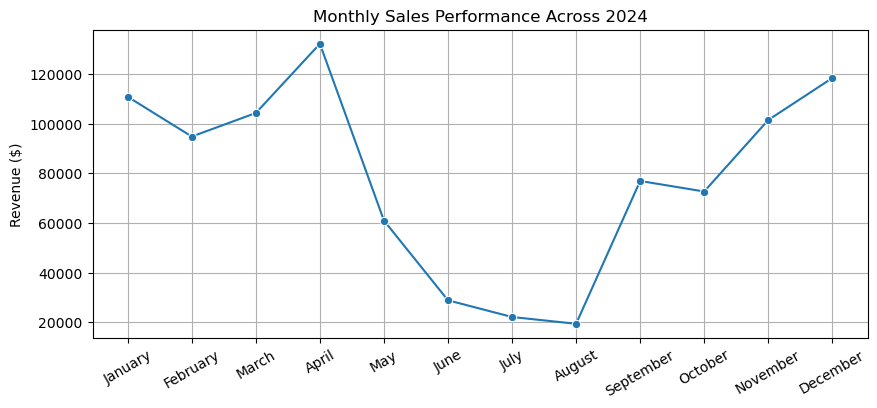

In [14]:
plt.figure(figsize=(10,4))
sns.lineplot(data=m_sales_trend, x='Month', y='Sales amount', marker='o')
plt.title('Monthly Sales Performance Across 2024')
plt.xlabel('')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=30)
plt.grid();

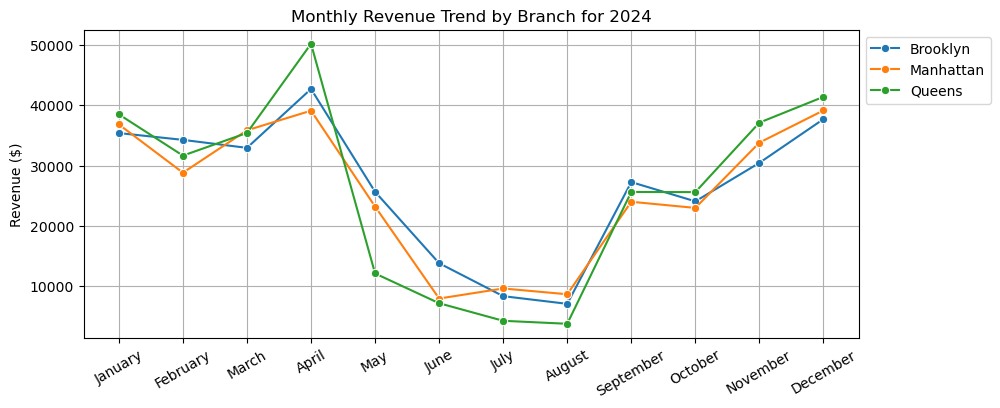

In [15]:
plt.figure(figsize=(10,4))
sns.lineplot(data=data, x='Month', y='Sales amount', hue='Branch', estimator='sum', marker='o', errorbar=None)
plt.legend(bbox_to_anchor=(1,1))
plt.title('Monthly Revenue Trend by Branch for 2024')
plt.xlabel('')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=30)
plt.grid();

### **3a. Month with the highest and lowest sale?**

In [16]:
m_sales_trend = m_sales_trend.sort_values('Sales amount', ascending=False).reset_index(drop=True)
m_sales_trend

,Month,Sales amount
0,April,132083.88
1,December,118295.12
2,January,110754.16
3,March,104243.34
4,November,101417.63
5,February,94761.64
6,September,76890.07
7,October,72651.64
8,May,60955.78
9,June,28883.41


In [17]:
print("""
Month with the highest sales is {}, with a total sales amount of ${}
Month with the lowest sales is {}, with a total sales amount of ${}

{}
""".format(m_sales_trend['Month'][0],
           m_sales_trend['Sales amount'][0],
           m_sales_trend['Month'][m_sales_trend.index[-1]],
           m_sales_trend['Sales amount'][m_sales_trend.index[-1]],
           m_sales_trend))


Month with the highest sales is April, with a total sales amount of $132083.88
Month with the lowest sales is August, with a total sales amount of $19440.15

        Month  Sales amount
0       April     132083.88
1    December     118295.12
2     January     110754.16
3       March     104243.34
4    November     101417.63
5    February      94761.64
6   September      76890.07
7     October      72651.64
8         May      60955.78
9        June      28883.41
10       July      22168.03
11     August      19440.15



## **2. Compare Sales Performance Across Branches**

### **2a. Branch generating the highest revenue?**

In [18]:
branch_revenue = data.groupby('Branch', as_index=False, observed=False)['Sales amount'].sum().sort_values('Sales amount', ascending=False).reset_index(drop=True)
branch_revenue

,Branch,Sales amount
0,Brooklyn,319705.48
1,Queens,312842.82
2,Manhattan,309996.55


### **2b. Branch selling the highest quantity of products?**

In [19]:
branch_quantity = data.groupby('Branch', as_index=False, observed=False)['Quantity'].sum().sort_values('Quantity', ascending=False).reset_index(drop=True)
branch_quantity

,Branch,Quantity
0,Brooklyn,7911
1,Manhattan,7752
2,Queens,7548


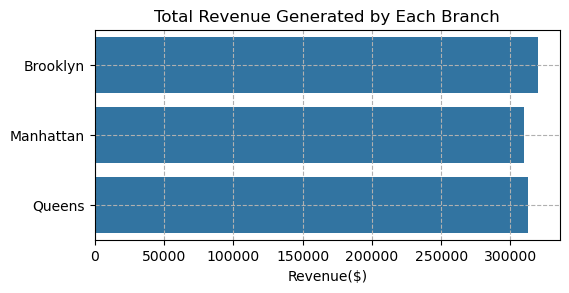

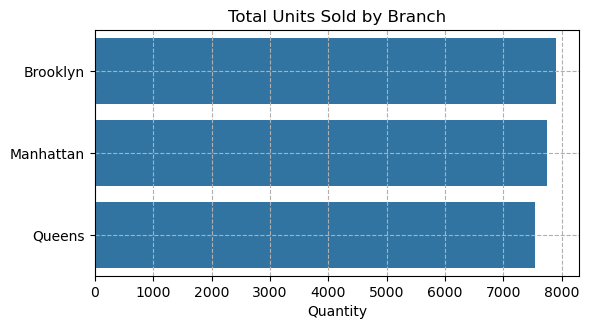

In [20]:
plt.figure(figsize=(6,6))
plt.subplot(2,1,1)
sns.barplot(data=branch_revenue, y='Branch', x='Sales amount')
plt.title('Total Revenue Generated by Each Branch')
plt.xlabel('Revenue($)')
plt.ylabel('')
plt.grid(linestyle='--')

plt.figure(figsize=(6,6))
plt.subplot(2,1,2)
sns.barplot(data=branch_quantity, y='Branch', x='Quantity')
plt.title('Total Units Sold by Branch')
plt.xlabel('Quantity')
plt.ylabel('')
plt.grid(linestyle='--')

plt.tight_layout()
plt.show;

### **2c. Any Branch underperforming?**

**Answer: No**

## **3. Identify Best-Selling-Product Lines**

### **3a. Product line generating the most revenue?**

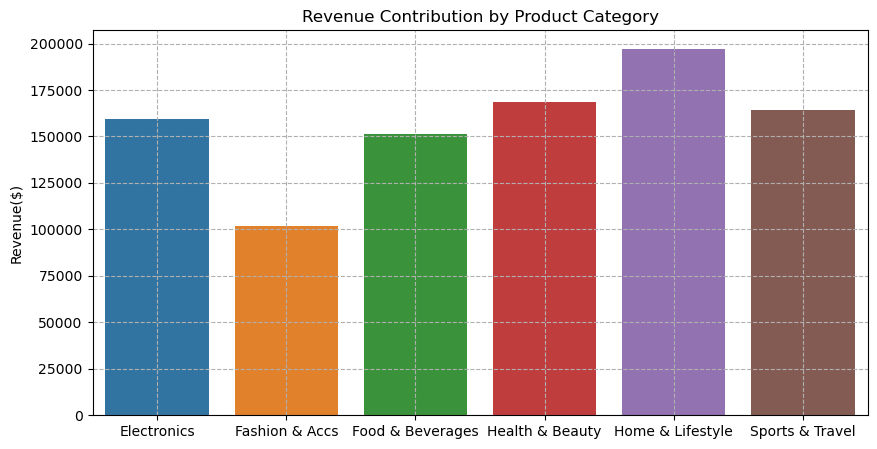

In [21]:
plt.figure(figsize=(10,5))
sns.barplot(data=data, x='Product line', y='Sales amount', estimator='sum', errorbar=None, hue='Product line')
plt.title('Revenue Contribution by Product Category')
plt.ylabel('Revenue($)')
plt.xlabel('')
plt.grid(linestyle='--');

In [22]:
product_line_revenue = data.groupby('Product line', as_index=False, observed=False)['Sales amount'].sum().sort_values('Sales amount').reset_index(drop=True)
product_line_revenue

,Product line,Sales amount
0,Fashion & Accs,101843.91
1,Food & Beverages,151357.73
2,Electronics,159259.10
3,Sports & Travel,164252.94
4,Health & Beauty,168570.61
5,Home & Lifestyle,197260.56


### **3b. Product line selling the most unit?**

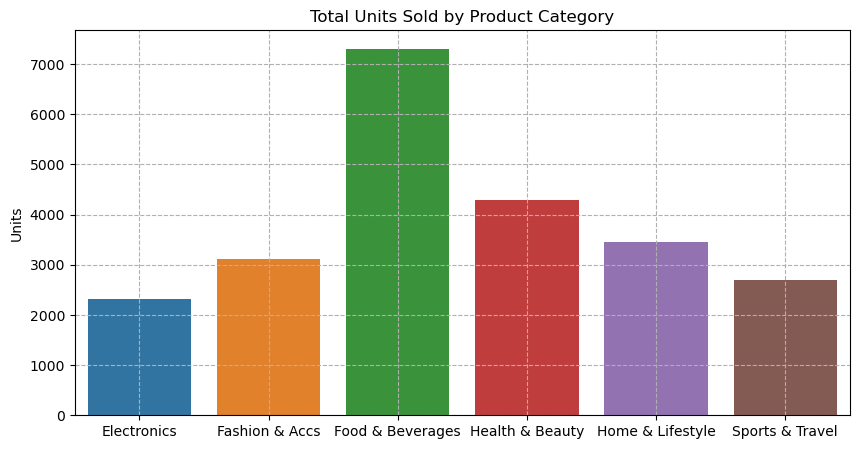

In [23]:
plt.figure(figsize=(10,5))
sns.barplot(data=data, x='Product line', y='Quantity', estimator='sum', errorbar=None, hue='Product line')
plt.title('Total Units Sold by Product Category')
plt.ylabel('Units')
plt.xlabel('')
plt.grid(linestyle='--');

In [24]:
product_line_quantity = data.groupby('Product line', as_index=False, observed=False)['Quantity'].sum().sort_values('Quantity').reset_index(drop=True)
product_line_quantity

,Product line,Quantity
0,Electronics,2325
1,Sports & Travel,2697
2,Fashion & Accs,3123
3,Home & Lifestyle,3461
4,Health & Beauty,4296
5,Food & Beverages,7309


### **3c. Category performing poorly?**

## **4. Understand Customer Segments**

### **4a. Do members spend more than normal customer?**

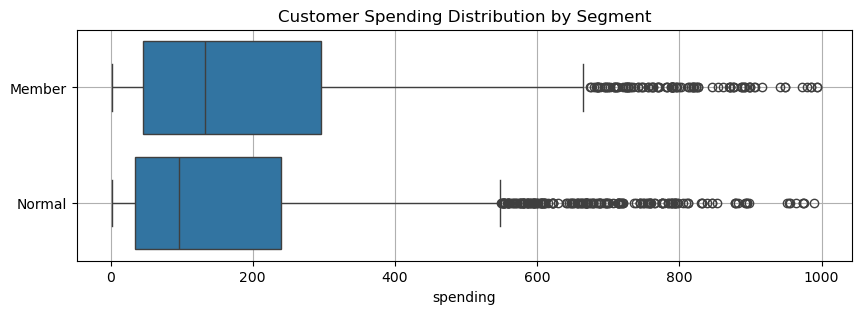

In [25]:
plt.figure(figsize= (10,3))
sns.boxplot(data=data, x='Sales amount', y='Customer type')
plt.xlabel('spending')
plt.ylabel('')
plt.title('Customer Spending Distribution by Segment')
plt.grid();

In [26]:
customer_type = data.groupby('Customer type', as_index=False, observed=False)['Sales amount'].mean().round(1)
customer_type

,Customer type,Sales amount
0,Member,209.3
1,Normal,170.5


In [27]:
member = data[data['Customer type'] == 'Member']
member.sample(3)

,Date,Branch,Customer type,Gender,Product line,Unit price,Quantity,Payment,Rating,Sales amount,Month
3871,2024-10-26,Brooklyn,Member,Male,Fashion & Accs,11.68,4,Ewallet,6.7,46.72,October
4829,2024-12-21,Brooklyn,Member,Female,Food & Beverages,9.92,2,Ewallet,8.6,19.84,December
3100,2024-09-03,Queens,Member,Male,Sports & Travel,77.73,7,Ewallet,4.3,544.11,September


In [28]:
member25 = np.percentile(member['Sales amount'], 25).round(1)
member50 = np.percentile(member['Sales amount'], 50).round(1)
member75 = np.percentile(member['Sales amount'], 75).round(1)
member100 = np.percentile(member['Sales amount'], 100).round(1)

In [29]:
normal = data[data['Customer type'] == 'Normal']
normal.sample(3)

,Date,Branch,Customer type,Gender,Product line,Unit price,Quantity,Payment,Rating,Sales amount,Month
2504,2024-07-17,Brooklyn,Normal,Female,Food & Beverages,3.43,4,Ewallet,8.3,13.72,July
2176,2024-06-22,Manhattan,Normal,Male,Food & Beverages,4.34,4,Ewallet,7.7,17.36,June
2214,2024-06-26,Queens,Normal,Male,Health & Beauty,39.30,3,Credit card,7.4,117.90,June


In [30]:
normal25 = np.percentile(normal['Sales amount'], 25).round(1)
normal50 = np.percentile(normal['Sales amount'], 50).round(1)
normal75 = np.percentile(normal['Sales amount'], 75).round(1)
normal100 = np.percentile(normal['Sales amount'], 100).round(1)

In [31]:
list1 = [member25,member50,member75,member100]
list2 = [normal25,normal50,normal75,normal100]

dict1={}
dict1['Member'] = list1
dict1['Normal'] = list2
index = ['25 percentile', '50 percentile', '75 percentile', '100 percentile']

pd.DataFrame(dict1, index=index)

,Member,Normal
25 percentile,46.1,34.9
50 percentile,133.2,96.6
75 percentile,296.7,240.2
100 percentile,993.0,989.8


### **4b. Which customer group generates higher revenue?**

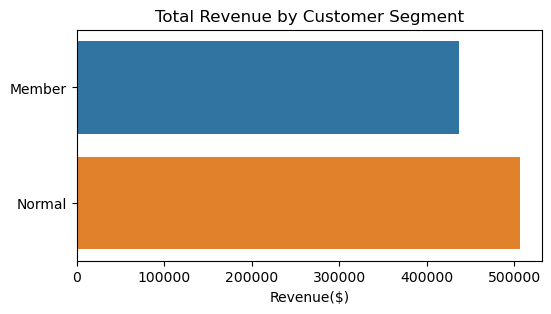

In [32]:
plt.figure(figsize=(6,3))
sns.barplot(data=data, y='Customer type', x='Sales amount', estimator='sum', errorbar=None, hue='Customer type');
plt.xlabel('Revenue($)')
plt.ylabel('')
plt.title('Total Revenue by Customer Segment');

In [33]:
d = data.groupby('Customer type', as_index=False, observed=False)['Sales amount'].sum()
d

,Customer type,Sales amount
0,Member,436368.17
1,Normal,506176.68


### **4c. Are there gender-based purchasing patterns?**

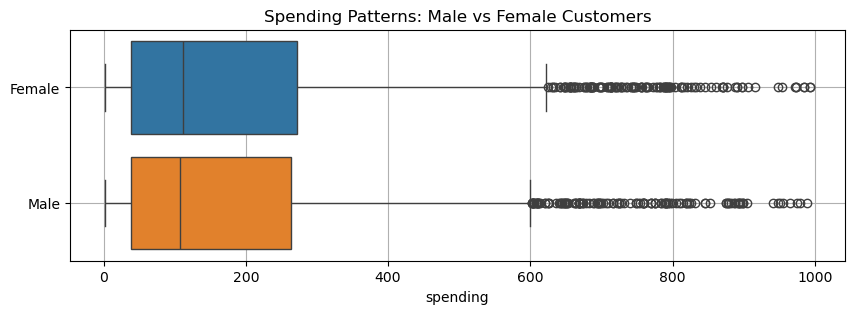

In [34]:
plt.figure(figsize= (10,3))
sns.boxplot(data=data, x='Sales amount', y='Gender', hue='Gender')
plt.xlabel('spending')
plt.ylabel('')
plt.title('Spending Patterns: Male vs Female Customers')
plt.grid();

## **5. Analyzing Payment Method Preferences**

### **5a. Which payment Method is used the most?**

In [35]:
a = data.groupby('Payment', as_index=False)['Payment'].size()
a

C:\Users\DELL\AppData\Local\Temp\ipykernel_4388\65464331.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a = data.groupby('Payment', as_index=False)['Payment'].size()


,Payment,size
0,Cash,1674
1,Credit card,1594
2,Ewallet,1785


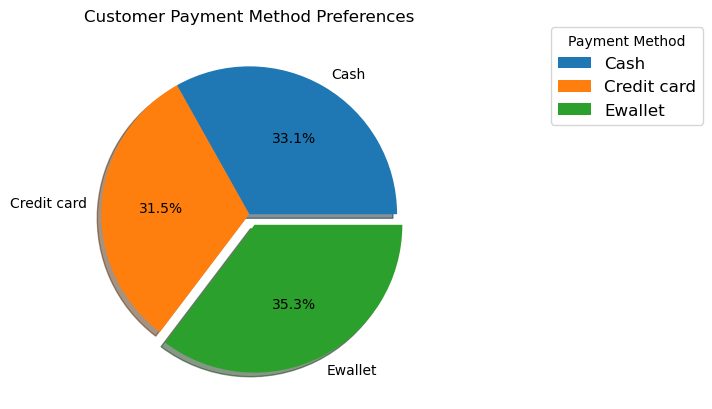

In [36]:
plt.pie(x=a['size'].unique(), labels=a['Payment'].unique(), shadow=True,  explode=[0,0,0.08],autopct ='%.1f%%')
plt.legend(title='Payment Method', loc = 4,fontsize  = 12, bbox_to_anchor =(1.75, 0.72), ncol = 1)
plt.title('Customer Payment Method Preferences');

### **5b. Do certian branches prefer specific payment types?**

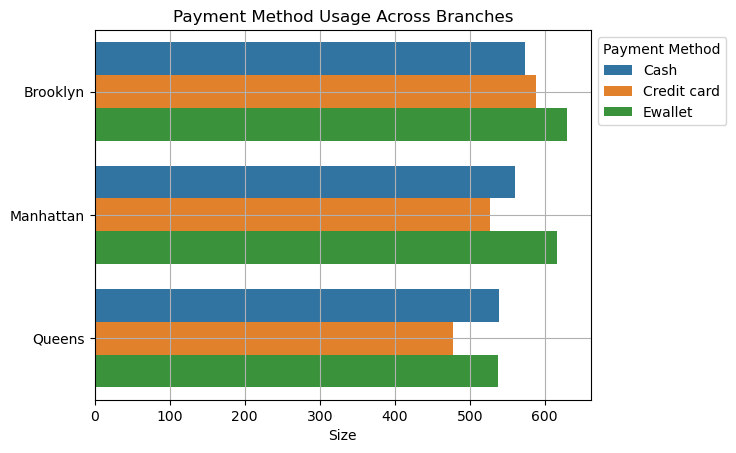

In [37]:
sns.countplot(data=data, y='Branch', hue='Payment')
plt.legend(title='Payment Method', bbox_to_anchor=(1,1))
plt.title('Payment Method Usage Across Branches')
plt.ylabel('')
plt.xlabel('Size')
plt.grid();

In [38]:
b = data.groupby(['Branch', 'Payment'], as_index=False, observed=False)[['Payment']].size()
b

,Branch,Payment,size
0,Brooklyn,Cash,574
1,Brooklyn,Credit card,589
2,Brooklyn,Ewallet,630
3,Manhattan,Cash,561
4,Manhattan,Credit card,527
5,Manhattan,Ewallet,617
6,Queens,Cash,539
7,Queens,Credit card,478
8,Queens,Ewallet,538


### **5c. Are digital payment increasing?**

In [39]:
c = data.groupby(['Month', 'Payment'], as_index=False, observed=False)[['Payment']].size()
c['Month'] = pd.Categorical(c['Month'], categories=month_order, ordered=True)
c = c.sort_values('Month').reset_index(drop=True)
c.sample(3)

,Month,Payment,size
23,August,Credit card,102
26,September,Ewallet,156
29,October,Ewallet,152


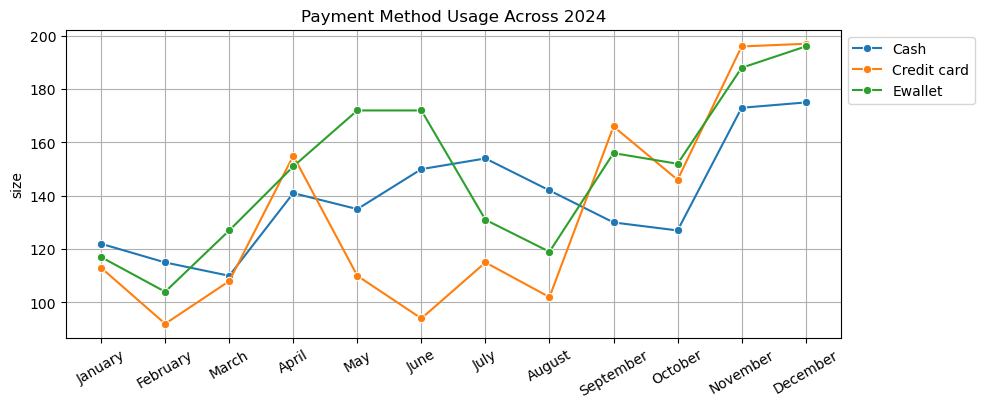

In [40]:
plt.figure(figsize=(10,4))
sns.lineplot(data=c, x='Month', y='size', marker='o', hue='Payment', n_boot=1000)
plt.legend(bbox_to_anchor=(1,1))
plt.title('Payment Method Usage Across 2024')
plt.xlabel('')
plt.xticks(rotation=30)
plt.grid();

## **6. Measure Customer Satisfaction**

### **6a. Average customer rating?**

In [41]:
avg_rating = data['Rating'].mean().round(1)
avg_rating

np.float64(6.9)

In [42]:
percentile50 = np.percentile(data['Rating'], 50)
percentile50

np.float64(7.1)

### **6b. Which branch has the highest satisfaction?**

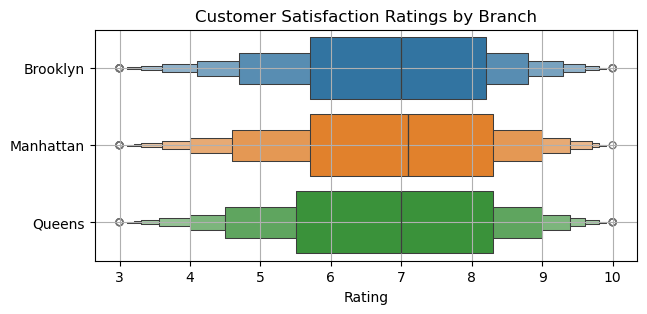

In [43]:
plt.figure(figsize= (7,3))
sns.boxenplot(data=data, y='Branch', x='Rating', hue='Branch')
plt.title('Customer Satisfaction Ratings by Branch')
plt.ylabel('')
plt.grid();

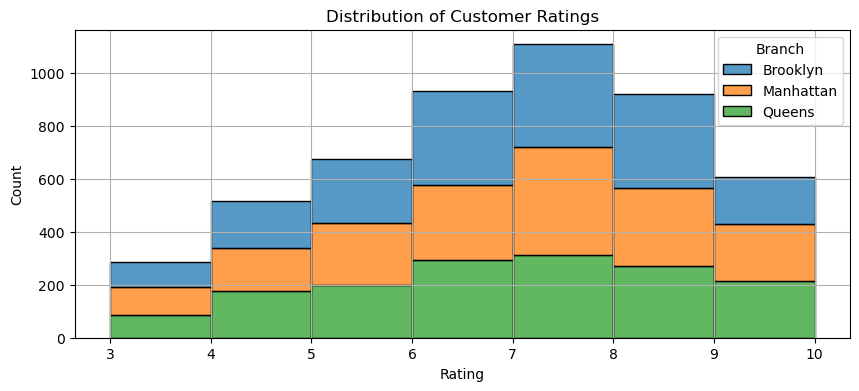

In [44]:
plt.figure(figsize=(10,4))
sns.histplot(data=data, x='Rating', bins=10, hue='Branch', binwidth=1, multiple='stack')
plt.title('Distribution of Customer Ratings')
plt.grid();

In [45]:
brooklyn50 = np.percentile(data[data['Branch']=='Brooklyn']['Rating'], 50)
Manhattan50 = np.percentile(data[data['Branch']=='Manhattan']['Rating'], 50)
Queens50 = np.percentile(data[data['Branch']=='Queens']['Rating'], 50)

print('''
50 percentile of the population of:
1. Brooklyn rated {} and below
2. Manhattan rated {} and below
3. Queens rated {} and below'''.format(brooklyn50, Manhattan50, Queens50))


50 percentile of the population of:
1. Brooklyn rated 7.0 and below
2. Manhattan rated 7.1 and below
3. Queens rated 7.0 and below


In [46]:
data.sample(4)

,Date,Branch,Customer type,Gender,Product line,Unit price,Quantity,Payment,Rating,Sales amount,Month
4342,2024-11-23,Manhattan,Normal,Male,Health & Beauty,17.65,1,Credit card,3.0,17.65,November
3339,2024-09-20,Queens,Member,Female,Fashion & Accs,22.83,8,Ewallet,4.9,182.64,September
589,2024-02-22,Brooklyn,Normal,Female,Fashion & Accs,47.44,1,Credit card,6.8,47.44,February
2977,2024-08-24,Manhattan,Normal,Female,Food & Beverages,7.35,4,Cash,7.0,29.40,August
